In [38]:
import  pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

excel_file = 'FAOSTAT_data.xlsx'

# Load the first sheet (or specify the sheet name)
df = pd.read_excel(excel_file, sheet_name=0)

# Save as CSV
df.to_csv('FAOSTAT_data.csv', index=False)


In [39]:
df=pd.read_csv('FAOSTAT_data.csv')
df.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2019,2019,ha,29203.0,A,Official figure,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2019,2019,kg/ha,1308.3,A,Official figure,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,1371,"Almonds, in shell",2019,2019,t,38205.0,A,Official figure,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2020,2020,ha,22134.0,A,Official figure,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2020,2020,kg/ha,1775.9,A,Official figure,NaN


In [7]:
df.drop('Year Code', axis=1,inplace=True) # remove the unwanted column
df.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2019,ha,29203.0,A,Official figure,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2019,kg/ha,1308.3,A,Official figure,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,1371,"Almonds, in shell",2019,t,38205.0,A,Official figure,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2020,ha,22134.0,A,Official figure,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2020,kg/ha,1775.9,A,Official figure,NaN


In [44]:
df.info() # checking the information of the dataset


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224647 entries, 0 to 224646
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Domain Code       224647 non-null  object 
 1   Domain            224647 non-null  object 
 2   Area Code (M49)   224647 non-null  int64  
 3   Area              224647 non-null  object 
 4   Element Code      224647 non-null  int64  
 5   Element           224647 non-null  object 
 6   Item Code (CPC)   224642 non-null  object 
 7   Item              224647 non-null  object 
 8   Year Code         224647 non-null  int64  
 9   Year              224647 non-null  int64  
 10  Unit              224645 non-null  object 
 11  Value             218130 non-null  float64
 12  Flag              224643 non-null  object 
 13  Flag Description  224634 non-null  object 
 14  Note              5098 non-null    object 
dtypes: float64(1), int64(4), object(10)
memory usage: 25.7+ MB


In [43]:
missing_data=df.isnull().sum() #checking the missing values in the dataset

percentage=(missing_data/len(df))*100
print(missing_data)
print(percentage)

Domain Code              0
Domain                   0
Area Code (M49)          0
Area                     0
Element Code             0
Element                  0
Item Code (CPC)          5
Item                     0
Year Code                0
Year                     0
Unit                     2
Value                 6517
Flag                     4
Flag Description        13
Note                219549
dtype: int64
Domain Code          0.000000
Domain               0.000000
Area Code (M49)      0.000000
Area                 0.000000
Element Code         0.000000
Element              0.000000
Item Code (CPC)      0.002226
Item                 0.000000
Year Code            0.000000
Year                 0.000000
Unit                 0.000890
Value                2.900996
Flag                 0.001781
Flag Description     0.005787
Note                97.730662
dtype: float64


In [51]:
df.drop('Note',axis=1,inplace=True) # removing the column with high null values

In [53]:
df.duplicated().sum() #checking the duplicates in the dataset
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [55]:
df.shape #checking the number of rows and column in dataset

(224647, 14)

In [59]:
df.describe() #checking the summary statistics of the dataset

,Area Code (M49),Element Code,Year Code,Year,Value
count,224647.000000,224647.000000,224647.000000,224647.000000,2.181300e+05
mean,426.797932,5407.125285,2020.971658,2020.971658,8.984848e+05
std,254.501789,101.321826,1.403592,1.403592,1.201902e+07
min,4.000000,5111.000000,2019.000000,2019.000000,0.000000e+00
25%,203.000000,5312.000000,2020.000000,2020.000000,9.370000e+02
50%,414.000000,5412.000000,2021.000000,2021.000000,7.228200e+03
75%,643.000000,5510.000000,2022.000000,2022.000000,5.135000e+04
max,894.000000,5513.000000,2023.000000,2023.000000,7.825858e+08


In [61]:
for column in df.columns:  # filling the null values with mean and mode value
    if df[column].dtype in ['int64','float64']:
        df[column].fillna(df[column].mean(), inplace=True)
    else:
        df[column].fillna(df[column].mode()[0], inplace=True)

print(df.isnull().sum())

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21040\612811282.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mode()[0], inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21040\612811282.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

Domain Code         0
Domain              0
Area Code (M49)     0
Area                0
Element Code        0
Element             0
Item Code (CPC)     0
Item                0
Year Code           0
Year                0
Unit                0
Value               0
Flag                0
Flag Description    0
dtype: int64


In [63]:
pro_col=['Area','Item','Element','Value','Year']  # separating the needed column form the dataset
filtered_data=df[pro_col]
print(filtered_data)

               Area                    Item         Element          Value  \
0       Afghanistan       Almonds, in shell  Area harvested   29203.000000   
1       Afghanistan       Almonds, in shell           Yield    1308.300000   
2       Afghanistan       Almonds, in shell      Production   38205.000000   
3       Afghanistan       Almonds, in shell  Area harvested   22134.000000   
4       Afghanistan       Almonds, in shell           Yield    1775.900000   
...             ...                     ...             ...            ...   
224642     Zimbabwe  Whole milk, evaporated      Production    5010.210000   
224643     Zimbabwe  Whole milk, evaporated      Production    4795.700000   
224644     Zimbabwe  Whole milk, evaporated      Production    4921.050000   
224645     Zimbabwe  Whole milk, evaporated      Production    4966.370000   
224646     Zimbabwe                    Wine      Production  898484.835892   

        Year  
0       2019  
1       2019  
2       2019  
3  

In [65]:
print(filtered_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224647 entries, 0 to 224646
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Area     224647 non-null  object 
 1   Item     224647 non-null  object 
 2   Element  224647 non-null  object 
 3   Value    224647 non-null  float64
 4   Year     224647 non-null  int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB
None


In [67]:
data=df[pro_col] # creating the subset for the selected columns
data

,Area,Item,Element,Value,Year
0,Afghanistan,"Almonds, in shell",Area harvested,29203.000000,2019
1,Afghanistan,"Almonds, in shell",Yield,1308.300000,2019
2,Afghanistan,"Almonds, in shell",Production,38205.000000,2019
3,Afghanistan,"Almonds, in shell",Area harvested,22134.000000,2020
4,Afghanistan,"Almonds, in shell",Yield,1775.900000,2020
...,...,...,...,...,...
224642,Zimbabwe,"Whole milk, evaporated",Production,5010.210000,2019
224643,Zimbabwe,"Whole milk, evaporated",Production,4795.700000,2020
224644,Zimbabwe,"Whole milk, evaporated",Production,4921.050000,2021
224645,Zimbabwe,"Whole milk, evaporated",Production,4966.370000,2022


In [69]:
pivot_data=data.pivot_table(index=['Area','Item','Year'], #pivot table
columns='Element',
values=('Value').reset_index()

In [71]:
pivot_data

Element,Area,Item,Year,Area harvested,Laying,Milk Animals,Producing Animals/Slaughtered,Production,Stocks,Yield,Yield/Carcass Weight
0,Afghanistan,"Almonds, in shell",2019,29203.0,NaN,NaN,NaN,38205.000000,NaN,1308.3,NaN
1,Afghanistan,"Almonds, in shell",2020,22134.0,NaN,NaN,NaN,39307.000000,NaN,1775.9,NaN
2,Afghanistan,"Almonds, in shell",2021,36862.0,NaN,NaN,NaN,64256.000000,NaN,1743.2,NaN
3,Afghanistan,"Almonds, in shell",2022,36462.0,NaN,NaN,NaN,63515.000000,NaN,1742.0,NaN
4,Afghanistan,"Almonds, in shell",2023,37000.0,NaN,NaN,NaN,67000.000000,NaN,1810.8,NaN
...,...,...,...,...,...,...,...,...,...,...,...
95920,Zimbabwe,"Whole milk, evaporated",2019,NaN,NaN,NaN,NaN,5010.210000,NaN,NaN,NaN
95921,Zimbabwe,"Whole milk, evaporated",2020,NaN,NaN,NaN,NaN,4795.700000,NaN,NaN,NaN
95922,Zimbabwe,"Whole milk, evaporated",2021,NaN,NaN,NaN,NaN,4921.050000,NaN,NaN,NaN
95923,Zimbabwe,"Whole milk, evaporated",2022,NaN,NaN,NaN,NaN,4966.370000,NaN,NaN,NaN


In [73]:
for column in pivot_data.columns:
    if pivot_data[column].dtype in ('int64', 'float64'):
        Q1=pivot_data[column].quantile(0.25)
        Q3=pivot_data[column].quantile(0.75)

        IQR=Q3-Q1

        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR

        outliers=pivot_data[(pivot_data[column]<lower_bound) | (pivot_data[column]>upper_bound)]
        print(outliers[[column]])
    else:
        print('error')

error
error
Empty DataFrame
Columns: [Year]
Index: []
Element  Area harvested
25              84070.0
26              86099.0
132             89593.0
133             92584.0
134             92645.0
...                 ...
95892           97138.0
95893          104759.0
95894           99029.0
95895          154023.0
95896          136126.0

[8811 rows x 1 columns]
Element   Laying
2539     44500.0
2540     44800.0
2541     47500.0
2542     51500.0
2543     51620.0
...          ...
94077    77070.0
94078    81688.0
94079    85874.0
94080    88710.0
94081    85424.0

[162 rows x 1 columns]
Element  Milk Animals
322         3478070.0
323         3523277.0
324         3567559.0
325         3648399.0
326         3709761.0
...               ...
92914       5205000.0
92915       5354000.0
92916       5523000.0
92917       5688000.0
93735       3301384.0

[298 rows x 1 columns]
Element  Producing Animals/Slaughtered
92                           3567060.0
93                           3616042.0


In [75]:
pivot_data.to_csv('Cleaned_Crop_data.csv',index=False)
print('its completed')

its completed


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21040\3497112566.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crop_counts.head(10).values, y=crop_counts.head(10).index, palette='viridis')


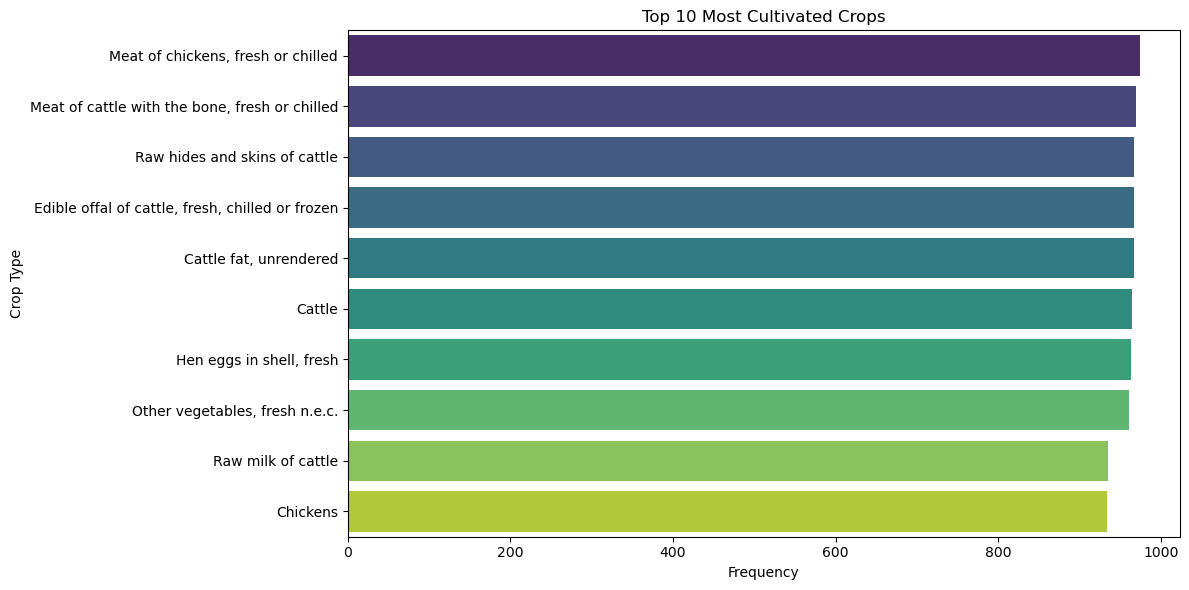

In [77]:
crop_counts = pivot_data['Item'].value_counts().sort_values(ascending=False)

# Plot the top 10 most cultivated crops
plt.figure(figsize=(12, 6))
sns.barplot(x=crop_counts.head(10).values, y=crop_counts.head(10).index, palette='viridis')
plt.title("Top 10 Most Cultivated Crops")
plt.xlabel("Frequency")
plt.ylabel("Crop Type")
plt.tight_layout()
plt.show()


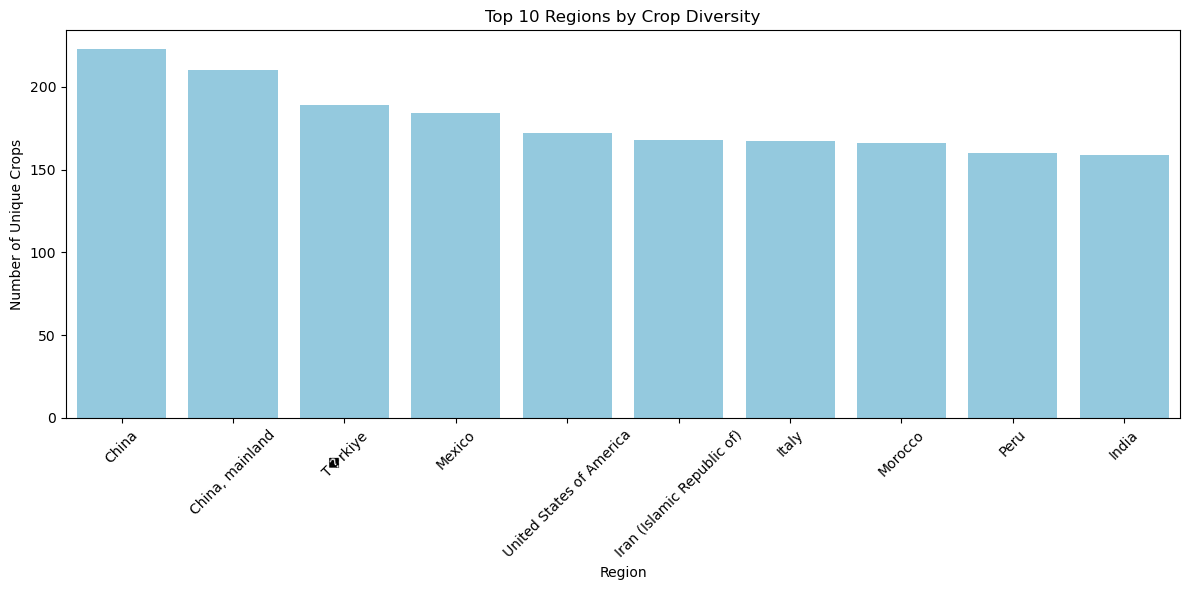

In [87]:
region_crop = pivot_data.groupby('Area')['Item'].nunique().sort_values(ascending=False)

region_data=pd.DataFrame(region_crop)

plt.figure(figsize=(12,6))
sns.barplot(x='Area',y='Item',data=region_data.head(10),color='skyblue')
plt.title("Top 10 Regions by Crop Diversity")
plt.xlabel("Region")
plt.ylabel("Number of Unique Crops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

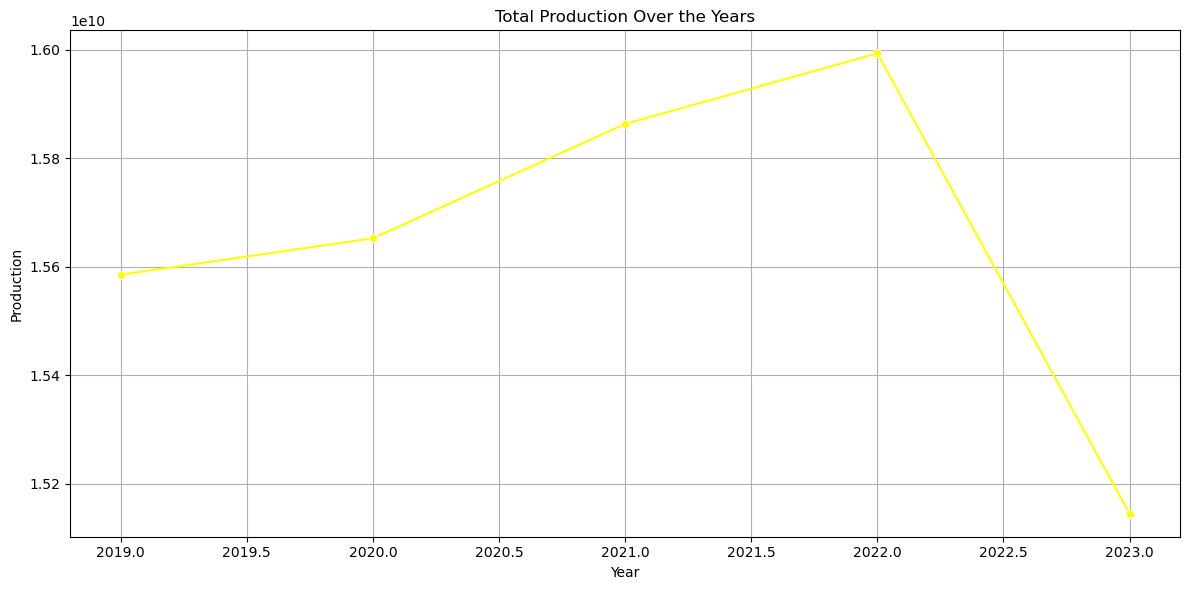

In [89]:
# Total production per year
yearly_production = pivot_data.groupby('Year')['Production'].sum()

plt.figure(figsize=(12,6))
sns.lineplot(x=pivot_data['Year'],y=pivot_data.groupby('Year')['Production'].sum(),marker='o', color='yellow')
plt.title("Total Production Over the Years")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid(True)
plt.tight_layout()
plt.show()

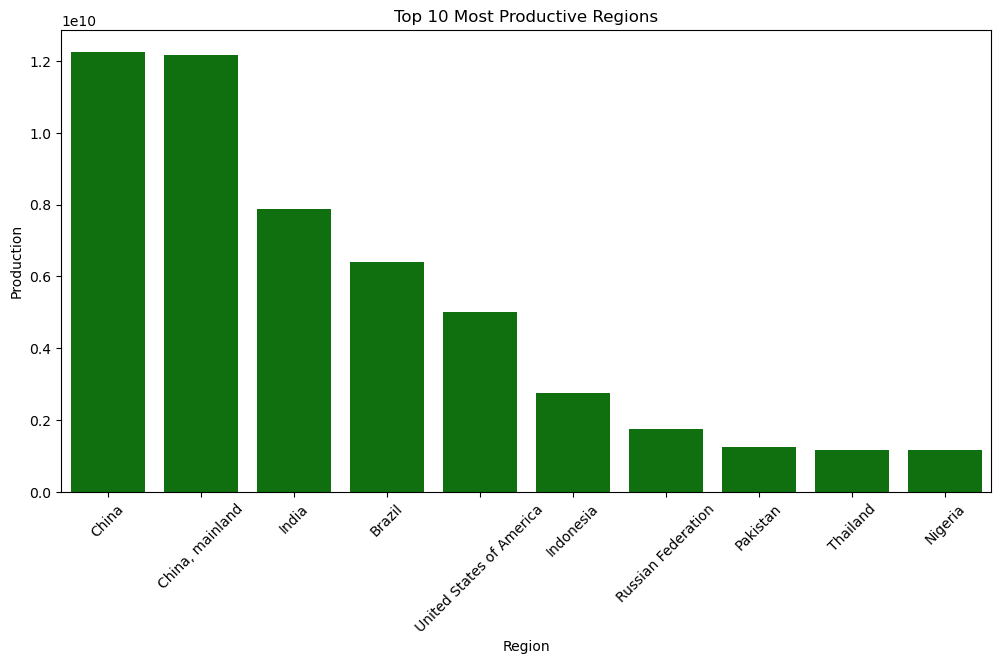

In [115]:
area_data=pivot_data.groupby('Area')['Production'].sum().sort_values(ascending=False)
area_df=pd.DataFrame(area_data)

plt.figure(figsize=(12,6))
sns.barplot(x='Area',y='Production',data=area_df.head(10),color='green')
plt.title('Top 10 Most Productive Regions')
plt.xlabel('Region')
plt.ylabel('Production')
plt.xticks(rotation=45)
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21040\1875086669.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


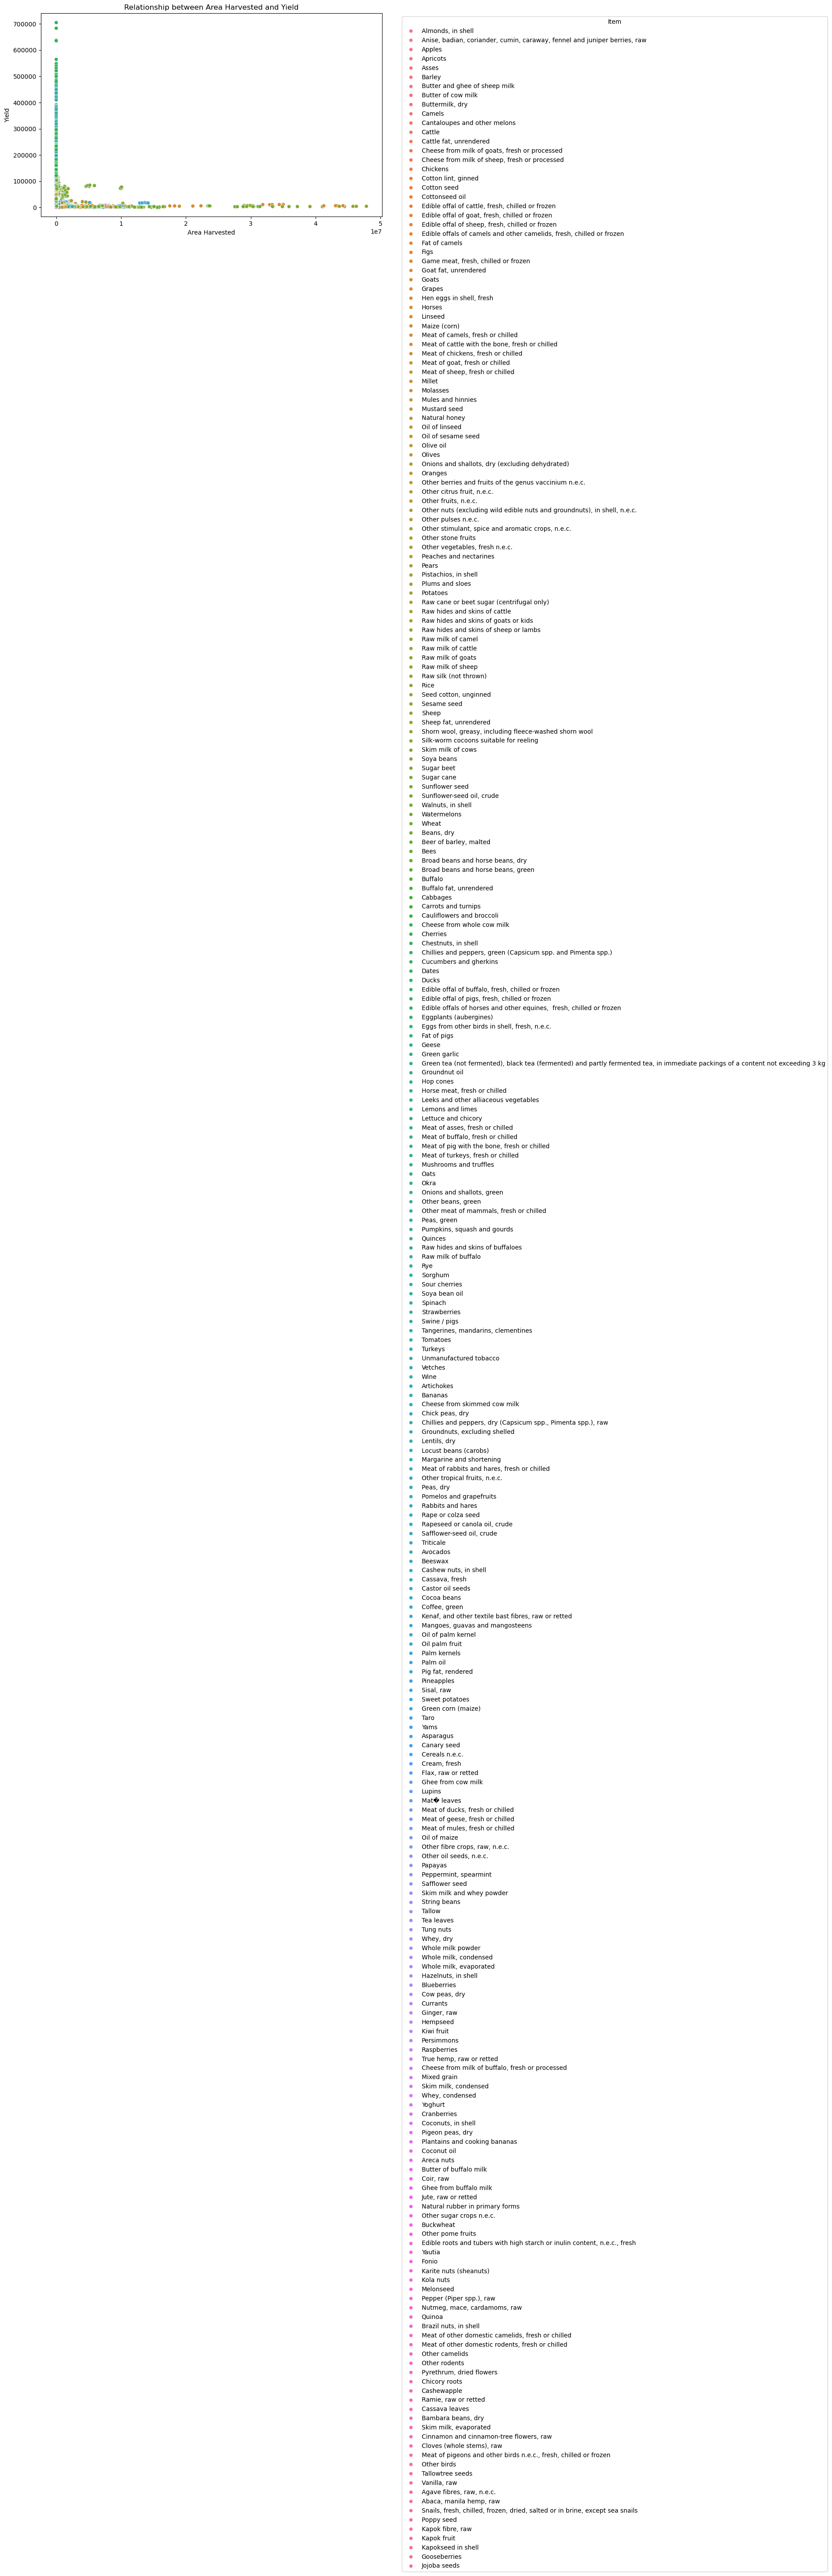

In [121]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pivot_data, x='Area harvested', y='Yield', hue='Item') 

plt.title('Relationship between Area Harvested and Yield')
plt.xlabel('Area Harvested')
plt.ylabel('Yield')
plt.legend(title='Item', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Element,Area harvested,Yield,Production
Element,,,
Area harvested,1.000000,-0.026551,0.636603
Yield,-0.026551,1.000000,0.068794
Production,0.636603,0.068794,1.000000


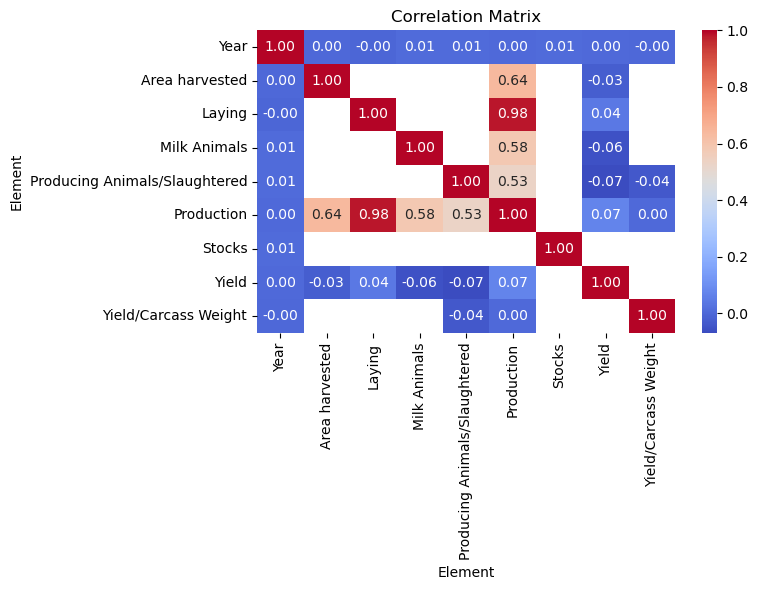

In [131]:
correlations = pivot_data[['Area harvested', 'Yield', 'Production']].corr()

style_tb=correlations.style.background_gradient(subset=['Area harvested', 'Yield', 'Production'],cmap='coolwarm')
display(style_tb)

plt.figure(figsize=(8,6))
sns.heatmap(pivot_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [133]:
crop_trends = pivot_data.groupby(["Year", "Item"])[["Yield", "Production"]].sum().reset_index()

# Display the data
print(crop_trends.head())

Element  Year                                               Item      Yield  \
0        2019                            Abaca, manila hemp, raw     5019.8   
1        2019                          Agave fibres, raw, n.e.c.     5968.8   
2        2019                                  Almonds, in shell   129126.1   
3        2019  Anise, badian, coriander, cumin, caraway, fenn...    64842.1   
4        2019                                             Apples  1646887.1   

Element    Production  
0        1.007991e+06  
1        3.959024e+04  
2        8.166503e+06  
3        4.952180e+06  
4        1.298731e+08  


In [135]:
crop_yield = pivot_data.groupby("Item")["Yield"].mean().reset_index()

# Sort crops by yield (highest to lowest)
crop_yield = crop_yield.sort_values(by="Yield", ascending=False)

# Display top and bottom crops
print("Top 5 High-Yield Crops:")
print(crop_yield.head())

print("Bottom 5 Low-Yield Crops:")
print(crop_yield.tail())

Top 5 High-Yield Crops:
                         Item         Yield
68     Cucumbers and gherkins  60452.688024
256                  Tomatoes  60133.858072
246                Sugar cane  58181.027426
245                Sugar beet  49593.234276
103  Hen eggs in shell, fresh  45664.779652
Bottom 5 Low-Yield Crops:
                       Item  Yield
269       Whole milk powder    NaN
270   Whole milk, condensed    NaN
271  Whole milk, evaporated    NaN
272                    Wine    NaN
275                 Yoghurt    NaN


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21040\2906981602.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combined, x='Yield', y='Item', palette='viridis')


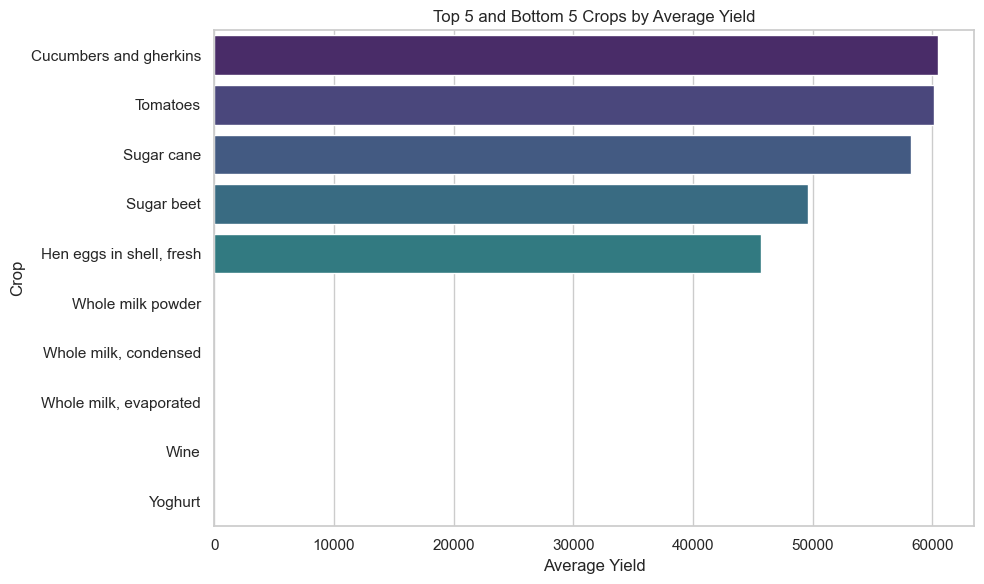

In [137]:
sns.set(style="whitegrid")

# Combine top and bottom crops into one DataFrame for easier plotting
top_crops = crop_yield.head(5)
bottom_crops = crop_yield.tail(5)
combined = pd.concat([top_crops, bottom_crops])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=combined, x='Yield', y='Item', palette='viridis')

plt.title('Top 5 and Bottom 5 Crops by Average Yield')
plt.xlabel('Average Yield')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

In [139]:
region_production = pivot_data.groupby("Area")["Production"].sum().reset_index()

# Sort by highest production
region_production = region_production.sort_values(by="Production", ascending=False)

# Display top and bottom regions
print(" Top 5 Highly Production Regions:")
print(region_production.head())

print(" Bottom 5 Low-Production Regions:")
print(region_production.tail())

 Top 5 Highly Production Regions:
                         Area    Production
34                      China  1.224804e+10
38            China, mainland  1.216462e+10
83                      India  7.877699e+09
22                     Brazil  6.402934e+09
191  United States of America  5.001834e+09
 Bottom 5 Low-Production Regions:
                      Area  Production
155  Sao Tome and Principe  553029.955
112       Marshall Islands  226750.440
63           Faroe Islands   49997.400
184                 Tuvalu   22577.355
123                  Nauru   15564.140


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21040\1998942569.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combined, x='Production', y='Area', palette='crest')


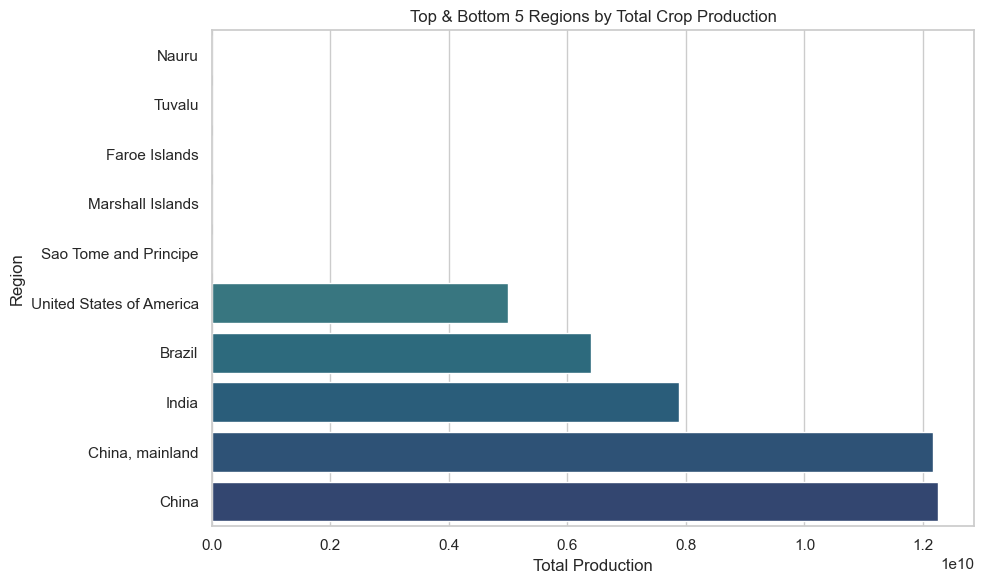

In [141]:
# Combine top and bottom 5 regions
top_regions = region_production.head(5)
bottom_regions = region_production.tail(5)
combined = pd.concat([top_regions, bottom_regions])

# Optional: sort for clean plotting
combined = combined.sort_values(by='Production', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=combined, x='Production', y='Area', palette='crest')

plt.title('Top & Bottom 5 Regions by Total Crop Production')
plt.xlabel('Total Production')
plt.ylabel('Region')
plt.tight_layout()
plt.show()


In [153]:
crop_efficiency = pivot_data.groupby('Item')['Yield'].mean().reset_index()
crop_efficiency = crop_efficiency.sort_values(by='Yield', ascending=False)

print("Top 5 Efficient Crops:")
print(crop_efficiency.head())

print("Bottom 5 Efficient Crops:")
print(crop_efficiency.tail())

Top 5 Efficient Crops:
                         Item         Yield
68     Cucumbers and gherkins  60452.688024
256                  Tomatoes  60133.858072
246                Sugar cane  58181.027426
245                Sugar beet  49593.234276
103  Hen eggs in shell, fresh  45664.779652
Bottom 5 Efficient Crops:
                       Item  Yield
269       Whole milk powder    NaN
270   Whole milk, condensed    NaN
271  Whole milk, evaporated    NaN
272                    Wine    NaN
275                 Yoghurt    NaN


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21040\2453693412.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bottom_crops, x='Yield', y='Item', palette='viridis')


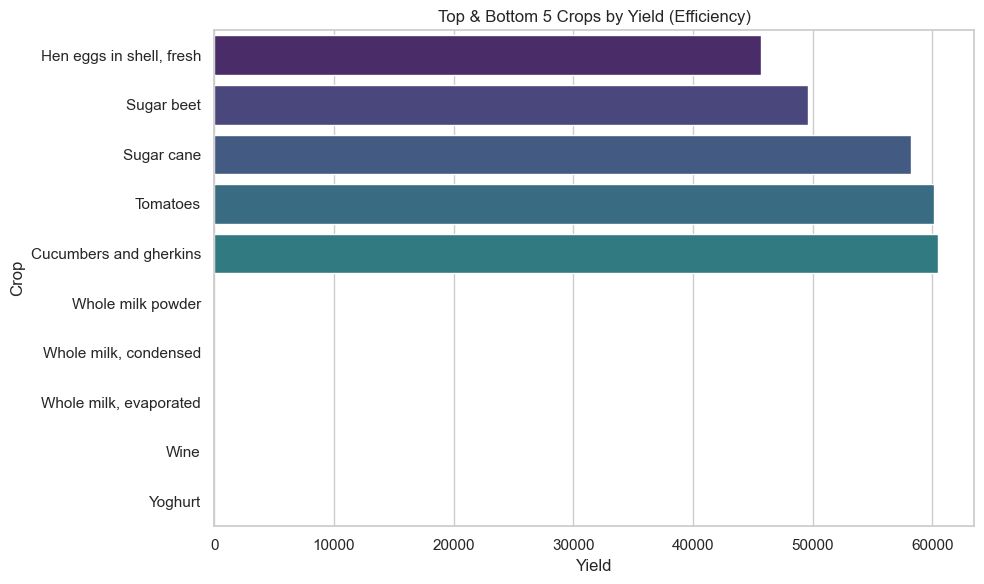

In [161]:
top_bottom_crops = pd.concat([crop_efficiency.head(5), crop_efficiency.tail(5)])
top_bottom_crops = top_bottom_crops.sort_values(by='Yield')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_bottom_crops, x='Yield', y='Item', palette='viridis')
plt.title('Top & Bottom 5 Crops by Yield (Efficiency)')
plt.xlabel('Yield')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

In [155]:
region_efficiency = pivot_data.groupby('Area')['Yield'].mean().reset_index()
region_efficiency = region_efficiency.sort_values(by='Yield', ascending=False)

print("Top 5 High-Productivity Regions:")
print(region_efficiency.head())

print("Bottom 5 Low-Productivity Regions:")
print(region_efficiency.tail())

Top 5 High-Productivity Regions:
                             Area          Yield
82                        Iceland  103546.890909
125  Netherlands (Kingdom of the)   65237.918957
15                        Belgium   59279.227000
78                         Guyana   45642.124898
87                        Ireland   42607.236607
Bottom 5 Low-Productivity Regions:
                         Area        Yield
69                     Gambia  3587.108000
178                      Togo  3502.416500
31   Central African Republic  3203.887895
113                Mauritania  2411.891852
59                    Eritrea  1632.264667


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21040\1681806571.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bottom_regions, x='Yield', y='Area', palette='crest')


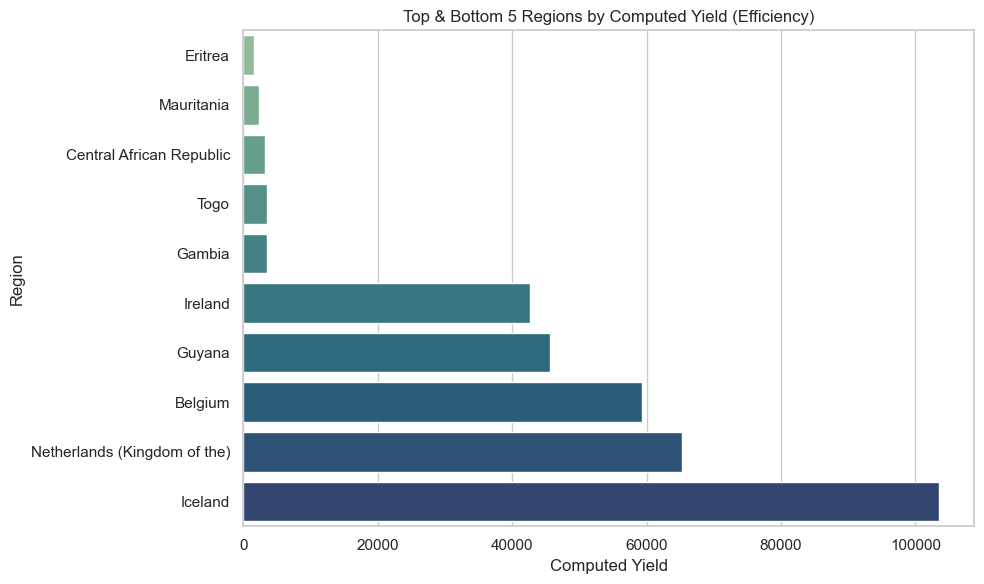

In [159]:
top_bottom_regions = pd.concat([region_efficiency.head(5), region_efficiency.tail(5)])
top_bottom_regions = top_bottom_regions.sort_values(by='Yield')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_bottom_regions, x='Yield', y='Area', palette='crest')
plt.title('Top & Bottom 5 Regions by Yield (Efficiency)')
plt.xlabel('Yield')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

In [163]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] < lower) | (df[column] > upper)]

In [165]:
yield_outliers = detect_outliers_iqr(pivot_data, 'Yield')
print("Yield Outliers:")
print(yield_outliers[['Year', 'Area', 'Item', 'Yield']])


Yield Outliers:
Element  Year      Area                    Item    Yield
478      2019   Albania                Cabbages  34805.2
479      2020   Albania                Cabbages  35825.2
482      2023   Albania                Cabbages  35277.8
492      2023   Albania     Carrots and turnips  37953.3
552      2019   Albania  Cucumbers and gherkins  47713.6
...       ...       ...                     ...      ...
95849    2020  Zimbabwe              Sugar cane  79000.0
95850    2021  Zimbabwe              Sugar cane  79000.0
95851    2022  Zimbabwe              Sugar cane  68502.0
95852    2023  Zimbabwe              Sugar cane  71125.5
95903    2020  Zimbabwe             Watermelons  36000.0

[4050 rows x 4 columns]


In [167]:
prod_outliers = detect_outliers_iqr(pivot_data, 'Production')
print("Production Outliers:")
print(prod_outliers[['Year', 'Area', 'Item', 'Production']])

Production Outliers:
Element  Year         Area                          Item     Production
47       2019  Afghanistan  Cantaloupes and other melons  464230.000000
48       2020  Afghanistan  Cantaloupes and other melons  793496.000000
49       2021  Afghanistan  Cantaloupes and other melons  763382.890000
50       2022  Afghanistan  Cantaloupes and other melons  762542.690000
51       2023  Afghanistan  Cantaloupes and other melons  795100.450000
...       ...          ...                           ...            ...
95882    2019     Zimbabwe                      Tomatoes  354603.000000
95883    2020     Zimbabwe                      Tomatoes  807150.000000
95884    2021     Zimbabwe                      Tomatoes  466596.470000
95886    2023     Zimbabwe                      Tomatoes  459036.500000
95924    2019     Zimbabwe                          Wine  898484.835892

[15014 rows x 4 columns]


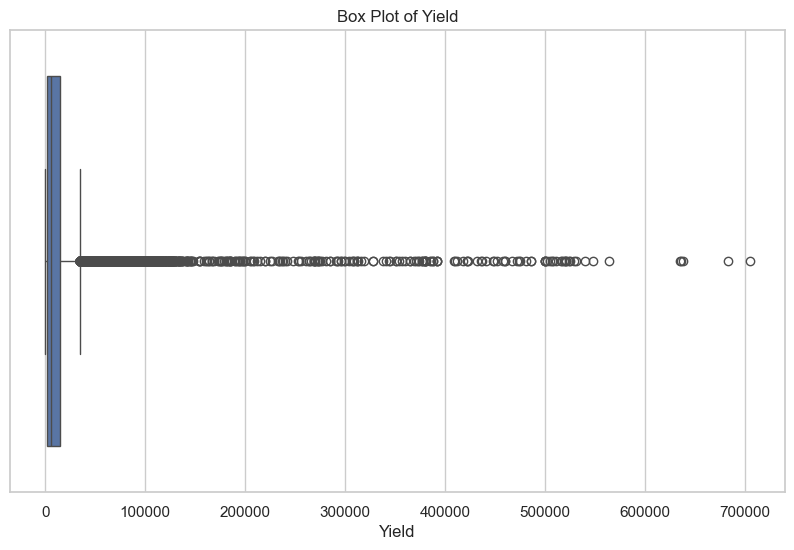

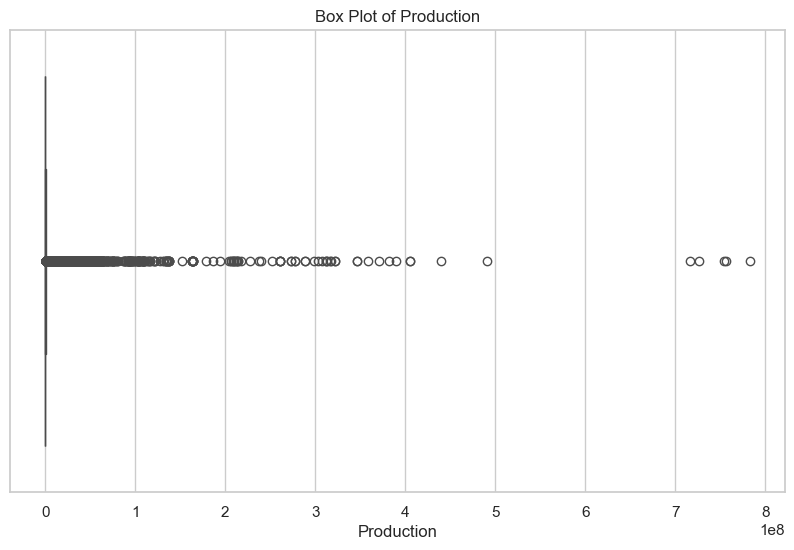

In [169]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=pivot_data, x='Yield')
plt.title('Box Plot of Yield')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=pivot_data, x='Production')
plt.title('Box Plot of Production')
plt.show()


In [171]:
unusual_yield_years = yield_outliers['Year'].value_counts().head()
print("Years with Most Yield Outliers:")
print(unusual_yield_years)

Years with Most Yield Outliers:
Year
2023    832
2021    814
2022    814
2020    803
2019    787
Name: count, dtype: int64
